# Introduction


We are using here the example from Unsloth for fine-tuning Gemma 4:E2B model.

In [1]:
!pip install -U -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Import packages

In [2]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset, Dataset
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare dataset

In [4]:
filename = "/kaggle/input/datasets/sbhatti/financial-sentiment-analysis/data.csv"
df = pd.read_csv(filename, encoding="utf-8", encoding_errors="replace")
df.columns = ["text", "sentiment"]
df.head()

,text,sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [5]:
X_train = list()
X_test = list()
for sentiment in ["positive", "neutral", "negative"]:
    train, test  = train_test_split(df[df.sentiment==sentiment], 
                                    train_size=300,
                                    test_size=300, 
                                    random_state=42)
    X_train.append(train)
    X_test.append(test)

X_train = pd.concat(X_train).sample(frac=1, random_state=10)
X_test = pd.concat(X_test)

eval_idx = [idx for idx in df.index if idx not in list(X_train.index) + list(X_test.index)]
X_eval = df[df.index.isin(eval_idx)]
X_eval = (X_eval
          .groupby('sentiment', group_keys=False)
          .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))
X_train = X_train.reset_index(drop=True)

/tmp/ipykernel_24/2194390274.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))


In [6]:
def generate_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = {data_point["sentiment"]}
            """.strip()

def generate_test_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = """.strip()

In [7]:
X_train = pd.DataFrame(X_train.apply(generate_prompt, axis=1), 
                       columns=["text"])
X_eval = pd.DataFrame(X_eval.apply(generate_prompt, axis=1), 
                      columns=["text"])

y_true = X_test.sentiment
X_test = pd.DataFrame(X_test.apply(generate_test_prompt, axis=1), columns=["text"])

train_data = Dataset.from_pandas(X_train)
eval_data = Dataset.from_pandas(X_eval)

In [8]:
def evaluate(y_true, y_pred):
    labels = ['positive', 'neutral', 'negative']
    mapping = {'positive': 2, 'neutral': 1, 'none':1, 'negative': 0}
    def map_func(x):
        return mapping.get(x, 1)
    
    y_true = np.vectorize(map_func)(y_true)
    y_pred = np.vectorize(map_func)(y_pred)

    # Class labels
    class_labels = ['negative', 'neutral', 'positive']

    # Calculate accuracy
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    print(f'Accuracy: {accuracy:.3f}')
    
    # Generate accuracy report
    unique_labels = set(y_true)  # Get unique labels
    
    for label in unique_labels:
        label_indices = [i for i in range(len(y_true)) 
                         if y_true[i] == label]
        label_y_true = [y_true[i] for i in label_indices]
        label_y_pred = [y_pred[i] for i in label_indices]
        accuracy = accuracy_score(label_y_true, label_y_pred)
        print(f'Accuracy for label {label}: {accuracy:.3f}')
        
    # Generate classification report
    class_report = classification_report(y_true=y_true, y_pred=y_pred, target_names=class_labels)
    print('\nClassification Report:')
    print(class_report)
    
    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=[0, 1, 2])
    print('\nConfusion Matrix:')
    print(conf_matrix)

    # Create a heatmap
    plt.figure(figsize=(6, 5))
   
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=class_labels, yticklabels=class_labels)
    
    # Add labels and title
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


# Initialize model

In [9]:
max_seq_length = 512  # start small; scale up after it works

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "google/gemma-4-E2b-it",
    max_seq_length = max_seq_length,
    load_in_4bit = False,     # MoE QLoRA not recommended, dense 27B is fine
    load_in_16bit = True,     # bf16/16-bit LoRA
    full_finetuning = False,
)

==((====))==  Unsloth 2026.4.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma4 won't work! Using float32.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

# Test the model without fine-tuning

In [10]:
from tqdm import tqdm
import torch
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

Gemma4ForConditionalGeneration(
  (model): Gemma4Model(
    (language_model): Gemma4TextModel(
      (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 1536, padding_idx=0)
      (layers): ModuleList(
        (0-3): 4 x Gemma4TextDecoderLayer(
          (self_attn): Gemma4TextAttention(
            (q_norm): Gemma4RMSNorm()
            (k_norm): Gemma4RMSNorm()
            (v_norm): Gemma4RMSNorm()
            (k_proj): Linear(in_features=1536, out_features=256, bias=False)
            (q_proj): Linear(in_features=1536, out_features=2048, bias=False)
            (v_proj): Linear(in_features=1536, out_features=256, bias=False)
            (o_proj): Linear(in_features=2048, out_features=1536, bias=False)
          )
          (mlp): Gemma4TextMLP(
            (gate_proj): Linear(in_features=1536, out_features=6144, bias=False)
            (up_proj): Linear(in_features=1536, out_features=6144, bias=False)
            (down_proj): Linear(in_features=6144, out_features=1536, bias=False)


In [11]:
def predict_batch(df, model, tokenizer, batch_size=8, max_new_tokens=5):
    y_pred = []
    texts = df["text"].tolist()

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        messages_batch = [
            [{"role": "user", "content": text}]
            for text in batch
        ]

        prompts = [
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
            for messages in messages_batch
        ]

        inputs = tokenizer(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(model.device)

        input_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )

        decoded = tokenizer.batch_decode(
            outputs[:, input_len:],
            skip_special_tokens=True
        )

        for out in decoded:
            out = out.strip().lower()

            if "positive" in out:
                y_pred.append("positive")
            elif "negative" in out:
                y_pred.append("negative")
            elif "neutral" in out:
                y_pred.append("neutral")
            else:
                y_pred.append("none")

    return y_pred

In [12]:
y_pred = predict_batch(X_test, model, tokenizer, batch_size=8)

100%|██████████| 113/113 [01:54<00:00,  1.01s/it]


Accuracy: 0.378
Accuracy for label 0: 0.113
Accuracy for label 1: 0.967
Accuracy for label 2: 0.053

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.11      0.20       300
     neutral       0.35      0.97      0.51       300
    positive       0.94      0.05      0.10       300

    accuracy                           0.38       900
   macro avg       0.68      0.38      0.27       900
weighted avg       0.68      0.38      0.27       900


Confusion Matrix:
[[ 34 266   0]
 [  9 290   1]
 [  2 282  16]]


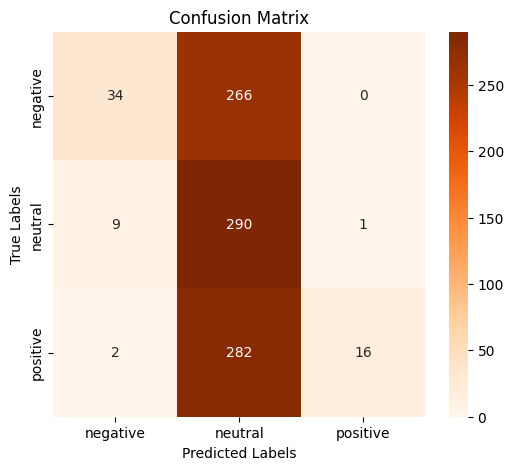

In [13]:
evaluate(y_true, y_pred)

# Prepare model for fine-tuning

In [14]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    # "unsloth" checkpointing is intended for very long context + lower VRAM
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    max_seq_length = max_seq_length,
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


Initially (1st Notebook version) we run for 100 steps, with `per_device_train_batch_size` = 1 and `gradient_accumulation_steps` = 4. That means that for our 900 samples, we didn't run even over all our samples.
We will run now again with the following changes:
* `num_train_epochs` = 5
* remove `max_steps` parameter
* change `logging steps` to 25

In [15]:
trainer = SFTTrainer(
    model = model,
    train_dataset = train_data,
    tokenizer = tokenizer,
    args = SFTConfig(
        max_seq_length = max_seq_length,
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 5,
        logging_steps = 25,
        output_dir = "outputs_gemma4_E2B",
        optim = "adamw_8bit",
        seed = 3407,
        dataset_num_proc = 1,
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=1):   0%|          | 0/900 [00:00<?, ? examples/s]

In [16]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 5 | Total steps = 1,125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 31,039,488 of 5,154,217,504 (0.60% trained)


Step,Training Loss
25,10.031869
50,3.522090
75,2.349847
100,2.076624
125,2.056467
150,2.003881
175,2.010260
200,1.926547
225,1.839201
250,2.138938


TrainOutput(global_step=1125, training_loss=2.377740912543403, metrics={'train_runtime': 2741.1544, 'train_samples_per_second': 1.642, 'train_steps_per_second': 0.41, 'total_flos': 5425226492313600.0, 'train_loss': 2.377740912543403, 'epoch': 5.0})

# Conlusions

We fine-tuned the model and saved the checkpoint. To use (and test) the trained model, use the following code:

```python
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-4-E2b-it",
    max_seq_length=512,
    load_in_4bit=False,
    load_in_16bit=True,
    full_finetuning=False,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    max_seq_length=512,
)

model.load_adapter("outputs_gemma4_E2B/checkpoint-xxx")
FastLanguageModel.for_inference(model)
```

Alternatively, you can try also:

```python
from peft import PeftModel

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-4-E2b-it",
    max_seq_length=512,
    load_in_4bit=False,
    load_in_16bit=True,
    full_finetuning=False,
)

model = PeftModel.from_pretrained(base_model, "outputs_gemma4_E2B/checkpoint-xxx")
FastLanguageModel.for_inference(model)
```

Here `checkpoint-xxx` is one of the checkpoints we select.